In [1]:
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from cuml.cluster import HDBSCAN


/home/gpuuser7/gpuuser7_a/prateek/LLM_with_ads/lmarena-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 1. Configuration
# ============================================================

INPUT_FILE = "/home/gpuuser7/gpuuser7_a/prateek/LLM_with_ads/data/processed/lmarena_dataset/arena_preference_en_single_turn.parquet"
OUTPUT_FILE = "lmarena_clustered.csv"
EMBEDDINGS_FILE = "/home/gpuuser7/gpuuser7_a/prateek/LLM_with_ads/data/processed/lmarena_query_embeddings_e5_large_v2.npz"

QUERY_COLUMN = "query"

MODEL_NAME = "intfloat/e5-large-v2"

BATCH_SIZE = 64
MIN_CLUSTER_SIZE = 30

In [3]:
# ============================================================
# 2. Check GPU
# ============================================================

if torch.cuda.is_available():
    device = "cuda"
    print("Using GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    device = "cpu"
    print("CUDA GPU not available. Using CPU.")

Using GPU: NVIDIA A100-SXM4-80GB
CUDA version: 12.6


In [4]:
# ============================================================
# 3. Load dataset
# ============================================================
df = pd.read_parquet(INPUT_FILE)

print("Number of rows:", len(df))

# Remove missing queries
df = df.dropna(subset=[QUERY_COLUMN]).copy()

# Convert to string
queries = df[QUERY_COLUMN].astype(str).tolist()

queries = [
    f"query: {q}"
    for q in queries
]

print("Number of valid queries:", len(queries))

Number of rows: 36579
Number of valid queries: 36579


In [5]:
# ============================================================
# 4. Load embedding model
# ============================================================

model = SentenceTransformer(
    MODEL_NAME,
    device=device
)

print("Model loaded on:", model.device)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 6741.40it/s]


Model loaded on: cuda:0


In [6]:
# ============================================================
# 5. Generate embeddings
# ============================================================

embeddings = model.encode(
    queries,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 572/572 [02:09<00:00,  4.43it/s]


Embedding shape: (36579, 1024)


In [7]:
# ============================================================
# 5b. Save embeddings
# ============================================================

np.savez_compressed(
    EMBEDDINGS_FILE,
    embeddings=embeddings,
    ids=df["id"].to_numpy() if "id" in df.columns else np.arange(len(embeddings)),
)

print("Saved embeddings to:", EMBEDDINGS_FILE)
print("Shape:", embeddings.shape)


Saved embeddings to: /home/gpuuser7/gpuuser7_a/prateek/LLM_with_ads/data/processed/lmarena_query_embeddings_e5_large_v2.npz
Shape: (36579, 1024)


In [8]:
# ============================================================
# 6. HDBSCAN clustering (GPU via cuML)
# ============================================================

clusterer = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

cluster_labels = clusterer.fit_predict(embeddings.astype(np.float32))
cluster_labels = np.asarray(cluster_labels)

df["cluster"] = cluster_labels
print("Clusters found:", len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))
print("Noise points:", int((cluster_labels == -1).sum()))


Clusters found: 16
Noise points: 35319


In [9]:
# ============================================================
# 7. Cluster statistics
# ============================================================

cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster distribution:")
print(cluster_counts)


Cluster distribution:
cluster
-1     35319
 0        49
 1        54
 2        42
 3        42
 4        56
 5       216
 6        42
 7        74
 8        95
 9        85
 10       37
 11      162
 12      110
 13       37
 14      111
 15       48
Name: count, dtype: int64


In [ ]:
# ============================================================
# 8. Save results
# ============================================================

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved to:", OUTPUT_FILE)

In [13]:
# ============================================================
# 9. Inspect all clusters
# ============================================================

N_SHOW = 8

for cid, n in df["cluster"].value_counts().sort_index().items():
    print("=" * 80)
    print(f"Cluster {cid} (n={n})")
    print("=" * 80)
    for i, q in enumerate(df.loc[df["cluster"] == cid, "query"].head(N_SHOW), 1):
        q = " ".join(str(q).split())
        # if len(q) > 180:
        #     q = q[:180] + "..."
        print(f"  {i}. {q}")
    print()


Cluster -1 (n=35319)
  1. Compare Tormenta20 with DnD5e
  2. What about 1 year in Sweden with proof e.g. travel, rental bookings, grocery receipts etc without personnummer and 4 with. EU citizen. Would this work?
  3. What are Tricky the Clown's forms?
  4. If I exercise until I feel that the muscle aches (though just a bit, no strong pain), is that enough for an exercise session? Especially by walking, when I feel the legs tired (after 8 to 10k steps says the phone), I call it a day.
  5. okay i am using you in intereview i will just give question little bit so you gave in 2-3 lines
  6. 1 word explanation of the German Expulsion after 1945.
  7. top 10 nike boots trending and new releases and prices
  8. What does the following GDScript function do?: func Sorted_Attribute_Transfer(From_Vertices, To_Vertices): var SortListA = From_Vertices.keys() SortListA.sort_custom(func(X, Y) -> bool: return To_Vertices[X] < To_Vertices[Y]) var SortListB = SortListA.duplicate(true) SortListB.sort_c

Loaded cached MiniLM embeddings: (36579, 384)
Computing MiniLM inertia for k = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  k= 2  inertia=34,482.4
  k= 3  inertia=34,045.2
  k= 4  inertia=33,764.8
  k= 5  inertia=33,530.0
  k= 6  inertia=33,321.6
  k= 7  inertia=33,104.1
  k= 8  inertia=32,919.9
  k= 9  inertia=32,746.3
  k=10  inertia=32,583.7
  k=11  inertia=32,442.9
  k=12  inertia=32,324.4
  k=13  inertia=32,182.2
  k=14  inertia=32,077.1
  k=15  inertia=31,964.4
  k=16  inertia=31,856.8
  k=17  inertia=31,755.4
  k=18  inertia=31,647.5
  k=19  inertia=31,578.2
  k=20  inertia=31,497.8
  k=21  inertia=31,407.0
  k=22  inertia=31,335.5
  k=23  inertia=31,243.3
  k=24  inertia=31,188.4
  k=25  inertia=31,117.9
  k=26  inertia=31,048.2
  k=27  inertia=30,979.1
  k=28  inertia=30,909.5
  k=29  inertia=30,863.6
  k=30  inertia=30,802.8

MiniLM elbow suggests k=11


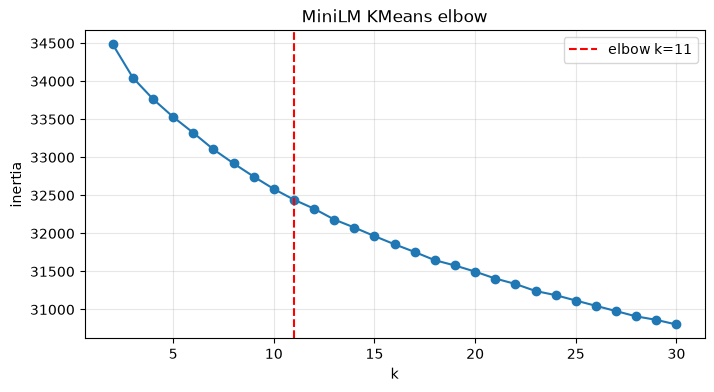


Fitting final MiniLM KMeans with k=11...

Cluster distribution:
cluster_alt
0     4328
1     3473
2     3177
3     3835
4     3635
5     1517
6     3317
7     1958
8     5288
9     3997
10    2054
Name: count, dtype: int64

--- Sample queries per cluster ---
MiniLM-KMeans cluster 0 (n=4328)
  1. If I exercise until I feel that the muscle aches (though just a bit, no strong pain), is that enough for an exercise session? Especially by walking, when I feel...
  2. Guess what I'm thinking.
  3. What is the "Abundance" argument in the context of US politics?
  4. Those are excellent thoughts! I will push back and offer that it's not conspiratorial, fringe, or 'out-there' to recognize there are certain areas of science th...
  5. Please write an SCP article about a hive mind that can infect and spread. It would like nothing more than to take control of all life. But it also suffers feeli...
  6. my ex says she loves me after breakup and marruying some one and 8 years of marriage and 2 kids


In [16]:
# ============================================================
# 10. Alt experiment: MiniLM embeddings + KMeans + elbow
# ============================================================

from pathlib import Path
from cuml.cluster import KMeans
import matplotlib.pyplot as plt

ALT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
ALT_EMBEDDINGS_FILE = "/home/gpuuser7/gpuuser7_a/prateek/LLM_with_ads/data/processed/lmarena_query_embeddings_minilm.npz"
K_RANGE = range(2, 31)
N_SHOW = 6

emb_path = Path(ALT_EMBEDDINGS_FILE)
if emb_path.exists():
    alt_embeddings = np.load(ALT_EMBEDDINGS_FILE, allow_pickle=True)["embeddings"]
    print("Loaded cached MiniLM embeddings:", alt_embeddings.shape)
else:
    alt_model = SentenceTransformer(ALT_MODEL_NAME, device=device)
    print("Alt model loaded on:", alt_model.device)
    alt_texts = df[QUERY_COLUMN].astype(str).tolist()
    alt_embeddings = alt_model.encode(
        alt_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    print("Alt embedding shape:", alt_embeddings.shape)
    np.savez_compressed(
        ALT_EMBEDDINGS_FILE,
        embeddings=alt_embeddings,
        ids=df["id"].to_numpy() if "id" in df.columns else np.arange(len(alt_embeddings)),
    )
    print("Saved:", ALT_EMBEDDINGS_FILE)

X_alt = alt_embeddings.astype(np.float32)

inertias_alt = []
print("Computing MiniLM inertia for k =", list(K_RANGE))
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_alt)
    inertias_alt.append(float(km.inertia_))
    print(f"  k={k:2d}  inertia={inertias_alt[-1]:,.1f}")

ks = np.asarray(list(K_RANGE), dtype=float)
ys = np.asarray(inertias_alt, dtype=float)
p1 = np.array([ks[0], ys[0]])
p2 = np.array([ks[-1], ys[-1]])
line = p2 - p1
line_norm = np.linalg.norm(line)
vecs = np.stack([ks, ys], axis=1) - p1
dists = np.abs(vecs[:, 0] * line[1] - vecs[:, 1] * line[0]) / line_norm
best_k_alt = int(ks[int(np.argmax(dists))])
print(f"\nMiniLM elbow suggests k={best_k_alt}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), inertias_alt, marker="o")
ax.axvline(best_k_alt, color="red", linestyle="--", label=f"elbow k={best_k_alt}")
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("MiniLM KMeans elbow")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"\nFitting final MiniLM KMeans with k={best_k_alt}...")
alt_kmeans = KMeans(n_clusters=best_k_alt, random_state=42, n_init=10)
alt_labels = np.asarray(alt_kmeans.fit_predict(X_alt))
df["cluster_alt"] = alt_labels

alt_counts = df["cluster_alt"].value_counts().sort_index()
print("\nCluster distribution:")
print(alt_counts)

print("\n--- Sample queries per cluster ---")
for cid, n in alt_counts.items():
    print("=" * 80)
    print(f"MiniLM-KMeans cluster {cid} (n={n})")
    print("=" * 80)
    for i, q in enumerate(df.loc[df["cluster_alt"] == cid, "query"].head(N_SHOW), 1):
        q = " ".join(str(q).split())
        if len(q) > 160:
            q = q[:160] + "..."
        print(f"  {i}. {q}")
    print()


Computing inertia for k = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  k= 2  inertia=9,705.4
  k= 3  inertia=9,597.8
  k= 4  inertia=9,512.2
  k= 5  inertia=9,442.2
  k= 6  inertia=9,379.0
  k= 7  inertia=9,313.0
  k= 8  inertia=9,261.1
  k= 9  inertia=9,216.4
  k=10  inertia=9,176.0
  k=11  inertia=9,135.2
  k=12  inertia=9,102.7
  k=13  inertia=9,076.8
  k=14  inertia=9,047.0
  k=15  inertia=9,014.3
  k=16  inertia=8,997.2
  k=17  inertia=8,968.4
  k=18  inertia=8,945.7
  k=19  inertia=8,922.0
  k=20  inertia=8,900.9
  k=21  inertia=8,884.3
  k=22  inertia=8,861.0
  k=23  inertia=8,841.4
  k=24  inertia=8,823.4
  k=25  inertia=8,812.2
  k=26  inertia=8,789.5
  k=27  inertia=8,784.5
  k=28  inertia=8,770.9
  k=29  inertia=8,742.6
  k=30  inertia=8,724.4

Elbow suggests k=11


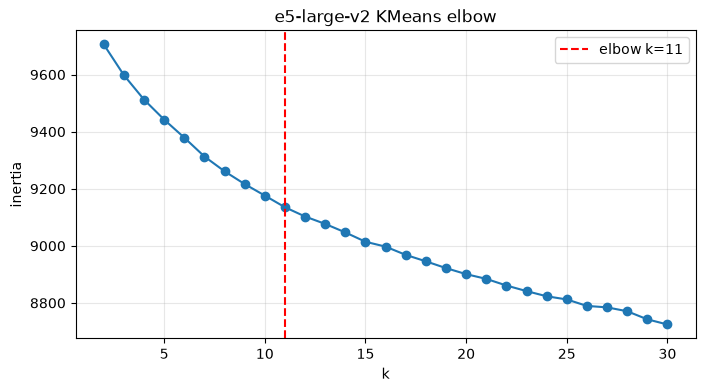


Fitting final KMeans with k=11...

Cluster distribution:
cluster_e5_kmeans
0     3906
1     3058
2     2750
3     4103
4     2304
5     4675
6     3576
7     3121
8     4061
9     3343
10    1682
Name: count, dtype: int64

--- Sample queries per cluster ---
e5-KMeans cluster 0 (n=3906)
  1. What are Tricky the Clown's forms?
  2. 1 word explanation of the German Expulsion after 1945.
  3. Tell me about the anime Creamy Mami
  4. Do you know kidzania? I used to go there as a child but in Indonesia. I heard that other countries also have them, can you describe the "jobs" that are not aval...
  5. how many people attended trumps parade this past weekend?
  6. Which is farther from London, Rome, or the Vatican?

e5-KMeans cluster 1 (n=3058)
  1. top 10 nike boots trending and new releases and prices
  2. Please name for me four wheelchair-friendly high end restaurants in Bangkok.
  3. What is the heaviest bird that can fly? Be concise.
  4. give an breif and indept analysis of best educat

In [15]:
# ============================================================
# 11. e5-large KMeans + elbow method
# ============================================================

from cuml.cluster import KMeans
import matplotlib.pyplot as plt

K_RANGE = range(2, 31)
N_SHOW = 6

X = embeddings.astype(np.float32)

inertias = []
print("Computing inertia for k =", list(K_RANGE))
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X)
    inertias.append(float(km.inertia_))
    print(f"  k={k:2d}  inertia={inertias[-1]:,.1f}")

# Elbow via max distance from first-last line (simple knee heuristic)
ks = np.asarray(list(K_RANGE), dtype=float)
ys = np.asarray(inertias, dtype=float)
p1 = np.array([ks[0], ys[0]])
p2 = np.array([ks[-1], ys[-1]])
line = p2 - p1
line_norm = np.linalg.norm(line)
# 2D distance from each point to the line between endpoints
line_unit = line / line_norm
vecs = np.stack([ks, ys], axis=1) - p1
# perpendicular distance in 2D: |vx*ly - vy*lx| / ||line||
dists = np.abs(vecs[:, 0] * line[1] - vecs[:, 1] * line[0]) / line_norm
best_k = int(ks[int(np.argmax(dists))])
print(f"\nElbow suggests k={best_k}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), inertias, marker="o")
ax.axvline(best_k, color="red", linestyle="--", label=f"elbow k={best_k}")
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("e5-large-v2 KMeans elbow")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"\nFitting final KMeans with k={best_k}...")
e5_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
e5_kmeans_labels = np.asarray(e5_kmeans.fit_predict(X))
df["cluster_e5_kmeans"] = e5_kmeans_labels

e5_counts = df["cluster_e5_kmeans"].value_counts().sort_index()
print("\nCluster distribution:")
print(e5_counts)

print("\n--- Sample queries per cluster ---")
for cid, n in e5_counts.items():
    print("=" * 80)
    print(f"e5-KMeans cluster {cid} (n={n})")
    print("=" * 80)
    for i, q in enumerate(df.loc[df["cluster_e5_kmeans"] == cid, "query"].head(N_SHOW), 1):
        q = " ".join(str(q).split())
        if len(q) > 160:
            q = q[:160] + "..."
        print(f"  {i}. {q}")
    print()
